### Objective

#### Imports

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sys

import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold, cross_val_predict, KFold
from sklearn.feature_selection import RFE
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel, SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, precision_score, roc_curve, auc, precision_recall_curve, average_precision_score, f1_score, recall_score
from sklearn.base import clone

#remove outliers (maybe)
#check imbalance (smote or undersample if needed)
#nested cross validation 
#mutual information for feature selection

#### Load preprocessed data

In [54]:
#Load the dataset
project_root = os.path.abspath(os.path.join('..'))

if project_root not in sys.path:
    sys.path.append(project_root)


from src.preprocessing import preprocess_data

file_path = r"../data/RA_Dataset.xlsx"
output_path = r"../data/RA_dataset_cleaned.csv"

df_cleaned=pd.read_pickle('data_cleaned.pkl')

#### Initial checks of the modeling dataset

In [55]:
df_cleaned.shape

(393, 55)

In [56]:
# Examine visit intervals and timeframes
print("Visit intervals between consecutive visits:")
df_sorted = df_cleaned.sort_values(['patient_id', 'visit_date'])
df_sorted['days_to_next_visit'] = df_sorted.groupby('patient_id')['visit_date'].diff().dt.days

print(f"Mean days between visits: {df_sorted['days_to_next_visit'].mean():.1f}")
print(f"Median days between visits: {df_sorted['days_to_next_visit'].median():.1f}")
print(f"Min: {df_sorted['days_to_next_visit'].min():.0f}, Max: {df_sorted['days_to_next_visit'].max():.0f}")
print(f"\nDistribution of days to next visit:")
print(df_sorted['days_to_next_visit'].describe())


Visit intervals between consecutive visits:
Mean days between visits: 234.3
Median days between visits: 181.0
Min: 14, Max: 1293

Distribution of days to next visit:
count     287.000000
mean      234.344948
std       191.733962
min        14.000000
25%       105.000000
50%       181.000000
75%       296.500000
max      1293.000000
Name: days_to_next_visit, dtype: float64


In [57]:
# Stratify by visit interval
print("\nBreakdown by visit interval:")
print(f"Visits <6 months (180 days): {(df_sorted['days_to_next_visit'] < 180).sum()} ({(df_sorted['days_to_next_visit'] < 180).sum()/len(df_sorted)*100:.1f}%)")
print(f"Visits 6-12 months (180-365 days): {((df_sorted['days_to_next_visit'] >= 180) & (df_sorted['days_to_next_visit'] < 365)).sum()} ({((df_sorted['days_to_next_visit'] >= 180) & (df_sorted['days_to_next_visit'] < 365)).sum()/len(df_sorted)*100:.1f}%)")
print(f"Visits >12 months: {(df_sorted['days_to_next_visit'] >= 365).sum()} ({(df_sorted['days_to_next_visit'] >= 365).sum()/len(df_sorted)*100:.1f}%)")

# Check flare rates by interval
print("\nFlare rates by visit interval:")
df_sorted['visit_interval'] = pd.cut(df_sorted['days_to_next_visit'], 
                                       bins=[0, 180, 365, 2000], 
                                       labels=['<6mo', '6-12mo', '>12mo'])
print(df_sorted.groupby('visit_interval')['flare_next_visit'].agg(['count', 'sum', 'mean']))


Breakdown by visit interval:
Visits <6 months (180 days): 142 (36.1%)
Visits 6-12 months (180-365 days): 94 (23.9%)
Visits >12 months: 51 (13.0%)

Flare rates by visit interval:
                count  sum      mean
visit_interval                      
<6mo              142   45  0.316901
6-12mo             94   28  0.297872
>12mo              51   16  0.313725


In [58]:
# Statistical test for flare rate differences by visit interval
from scipy.stats import chi2_contingency

# Create contingency table
contingency = pd.crosstab(df_sorted['visit_interval'], df_sorted['flare_next_visit'])
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi-square test for independence:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"\nConclusion: Flare rates {'DO NOT' if p_value > 0.05 else 'DO'} differ significantly across visit intervals (α=0.05)")

Chi-square test for independence:
Chi-square statistic: 0.0995
p-value: 0.9515
Degrees of freedom: 2

Conclusion: Flare rates DO NOT differ significantly across visit intervals (α=0.05)


#### Target Variable Definition
Our prediction target is **"flare occurrence at the patient's next scheduled visit"**, defined as a clinical flare in disease activity occurring between the index visit and the next follow-up visit. 

**Temporal characteristics:**
- Median follow-up interval: 181 days (6 months)
- IQR: 105-296 days
- Range: 14-1293 days

**Flare rates by follow-up interval:**
- <6 months (n=142): 31.7%
- 6-12 months (n=94): 29.8%
- >12 months (n=51): 31.4%

The consistency of flare rates across different visit intervals (p-value suggests no significant difference) validates our modeling approach, as it indicates that disease activity flares occur at relatively stable rates regardless of follow-up timing.


#### Define target, groups, and candidate features

In [59]:
#Define the target variable
target_variable = 'flare_next_visit'

#Drop the columns that are not needed for modeling plus the target variable, after EDA analysis.

drop_columns = [
    target_variable,
    'flare_event',
    'patient_id',
    'visit_date', 
    'source',
    'year_of_diagnosis',
    'crp_normalized',
    'crp_upper_limit',
    'crp',
    'esr',
    'mtx_use',
    'steroid_use',
    'mtx_dose_category',
    'steroid_dose_category',
    'comorbidities',
    'csdmard_name',
    'b_ts_dmard_name', 
    'switch_reason', 
    'treatment_decision',
    'birth_year',
    'das28_bins',
    'visit_type',
    'disease_duration',
    'comorb_renal_urological',
    'comorb_malignancy',
    'age_bins',
    'esr_missing',
    'crp_missing',
    'das28_missing'
    
]

#Define the feature matrix X 
X = df_cleaned.drop(columns = drop_columns, errors='ignore')

#Define the target variable y
y = df_cleaned[target_variable]

#Define the groups for group-aware splitting
groups = df_cleaned['patient_id']

In [60]:
print('x shape: ', X.shape)
print('y shape: ', y.shape)

x shape:  (393, 26)
y shape:  (393,)


In [61]:
X.columns.to_list()

['gender',
 'rf_status',
 'anti_ccp_status',
 'das28_score',
 'mtx_dose',
 'steroid_dose',
 'treatment_decision_grouped',
 'days_since_last_visit',
 'age_at_visit',
 'das28_change',
 'previous_flare',
 'inflammation_flag',
 'comorb_cardiovascular',
 'comorb_metabolic_endocrine',
 'comorb_respiratory',
 'comorb_gastrointestinal_hepatic',
 'comorb_musculoskeletal',
 'comorb_neurologic_psychiatric',
 'comorb_autoimmune_other',
 'comorbidity_count',
 'csdmard_use',
 'b_ts_dmard_use',
 'treatment_count',
 'log_crp_normalized',
 'log_esr',
 'log_disease_duration']

In [62]:
continuous_features = [
    'das28_change',
    'log_esr',
    'log_crp_normalized', 
    'steroid_dose',
    'mtx_dose',
    'age_at_visit',
    'log_disease_duration',
    'days_since_last_visit',
    'comorbidity_count',
    'treatment_count'
]

binary_features=[
    'gender',
    'rf_status',
    'anti_ccp_status',
    'csdmard_use',
    'b_ts_dmard_use',
    'inflammation_flag',
    'previous_flare',
    'comorb_cardiovascular',
    'comorb_metabolic_endocrine',
    'comorb_respiratory',
    'comorb_gastrointestinal_hepatic',
    'comorb_musculoskeletal',
    'comorb_autoimmune_other',
    'comorb_neurologic_psychiatric'
]

categorical_features = [
    'treatment_decision_grouped'
]

#### Build preprocessing pipeline

#### Mixed model imputation for DAS28
knn imputer, mice

In [63]:
from sklearn.impute import KNNImputer
das28_feature= ['das28_score', 'das28_change']
das28_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

In [64]:
group_kfold = GroupKFold(n_splits=5)
stratified_group_kfold = StratifiedGroupKFold(n_splits=5)
for i, (train_index, test_index) in enumerate(group_kfold.split(X, y, groups)):
    print(f"Fold {i}, overlap:", set(groups.iloc[train_index]).intersection(groups.iloc[test_index]))

Fold 0, overlap: set()
Fold 1, overlap: set()
Fold 2, overlap: set()
Fold 3, overlap: set()
Fold 4, overlap: set()


In [65]:
metrics = {
    accuracy_score: 'Accuracy',
    precision_score: 'Precision',
    recall_score: 'Recall',
    f1_score: 'F1 Score',
    roc_auc_score: 'ROC AUC',
    average_precision_score: 'Average Precision'
}

In [66]:
def evaluate_model(model, X, y, groups, cv, model_name="Model"):
    """
    Evaluate model using cross-validation and metrics dictionary.
    
    Args:
        model: Fitted model or pipeline
        X: Feature matrix
        y: Target variable
        groups: Group labels for grouped CV
        cv: Cross-validation splitter
        model_name: Name for display
    
    Returns:
        DataFrame with all metrics
    """
    # Get predictions
    y_pred = cross_val_predict(model, X, y, cv=cv, groups=groups, method='predict')
    y_pred_proba = cross_val_predict(model, X, y, cv=cv, groups=groups, method='predict_proba')[:, 1]
    
    # Calculate all metrics using dictionary
    results = {}
    for metric_func, metric_name in metrics.items():
        if metric_name in ['ROC AUC', 'Average Precision']:
            results[metric_name] = metric_func(y, y_pred_proba)
        elif metric_name == 'Accuracy':
            results[metric_name] = metric_func(y, y_pred)
        else:
            results[metric_name] = metric_func(y, y_pred)
    
    # Display results
    print(f"\n{'='*60}")
    print(f"{model_name.upper()}")
    print(f"{'='*60}")
    print(classification_report(y, y_pred))
    print(f"\nMetrics Summary:")
    for metric_name, score in results.items():
        print(f"  {metric_name.replace('_', ' ').title():20s}: {score:.4f}")
    print(f"{'='*60}\n")
    
    return y_pred, y_pred_proba, results


In [67]:
# def mi_discrete(X, y):
#     return mutual_info_classif(X, y, discrete_features=True, random_state=42)

# def mi_continuous(X, y):
#     # return mutual_info_classif(X, y, discrete_features=False, random_state=42)

#### Baseline models
We compare all four models together in their baseline phase in order to see differences


BASELINE CLASSIFIER COMPARISON
                          Accuracy      Precision         Recall       F1 Score        ROC AUC Average Precision
Logistic Regression  0.598 ± 0.087  0.421 ± 0.118  0.479 ± 0.135  0.440 ± 0.104  0.602 ± 0.113     0.487 ± 0.117
Random Forest        0.646 ± 0.077  0.468 ± 0.146  0.400 ± 0.115  0.427 ± 0.123  0.644 ± 0.104     0.479 ± 0.103
XGBoost              0.621 ± 0.046  0.413 ± 0.089  0.315 ± 0.052  0.356 ± 0.063  0.567 ± 0.084     0.422 ± 0.072
SVM                  0.585 ± 0.074  0.396 ± 0.093  0.448 ± 0.111  0.416 ± 0.090  0.612 ± 0.083     0.452 ± 0.071



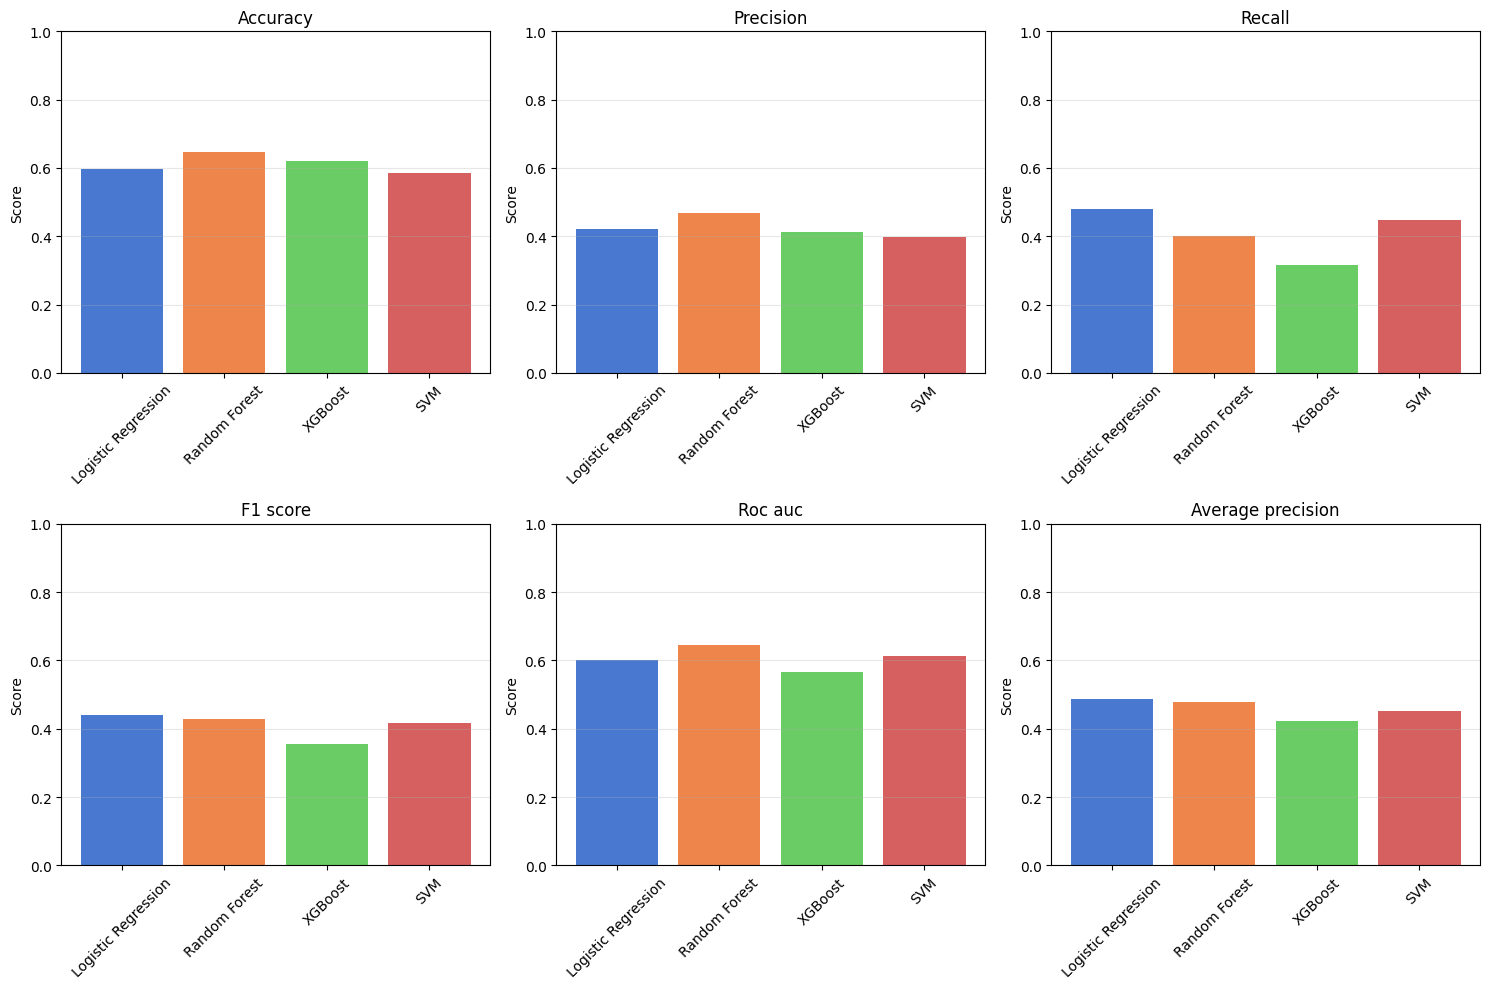

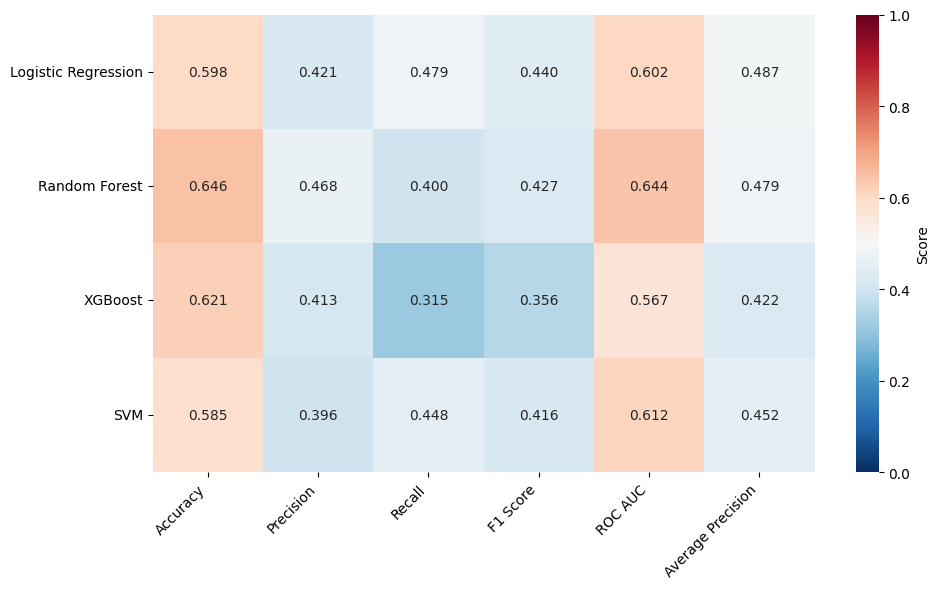

In [68]:
# Define preprocessing pipelines
preprocessor_baseline = ColumnTransformer(transformers=[
    ('cont', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())]), continuous_features),
        ('das28', das28_transformer, das28_feature),

    ('bin', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent'))]), binary_features),

    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
])

# Define baseline classifiers with optimized hyperparameters
baseline_classifiers = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor_baseline),
        ('classifier', LogisticRegression(max_iter=1000,
                                          class_weight='balanced',
                                          random_state=42))
    ]),

    'Random Forest': Pipeline([
        ('preprocessor', preprocessor_baseline),
        ('classifier', RandomForestClassifier(max_depth=5,
                                              min_samples_split=5, 
                                              min_samples_leaf=2, 
                                              class_weight='balanced', 
                                              random_state=42, 
                                              n_jobs=-1))
    ]),

    'XGBoost': Pipeline([
        ('preprocessor', preprocessor_baseline),
        ('classifier', XGBClassifier(max_depth=5,
                                     scale_pos_weight=(y == 0).sum() / (y == 1).sum(), 
                                     random_state=42, 
                                     eval_metric='logloss', 
                                     n_jobs=-1))
    ]),

    'SVM': Pipeline([
        ('preprocessor', preprocessor_baseline),
        ('classifier', SVC(class_weight='balanced', 
                           probability=True, 
                           random_state=42))
    ])
}

# Run cross-validation and collect results
cv_results = {}
metric_names = list(metrics.values())

for clf_name, clf_template in baseline_classifiers.items():
    cv_results[clf_name] = {metric: [] for metric in metric_names}
    
    for train_idx, test_idx in stratified_group_kfold.split(X, y, groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        clf = clone(clf_template)
        clf.fit(X_train, y_train)
        y_pred, y_pred_proba = clf.predict(X_test), clf.predict_proba(X_test)[:, 1]
        
        for metric_func, metric_name in metrics.items():
            if metric_name in ['ROC AUC', 'Average Precision']:
                score = metric_func(y_test, y_pred_proba)
            elif metric_name == 'Accuracy':
                score = metric_func(y_test, y_pred)
            else:
                score = metric_func(y_test, y_pred, zero_division=0)
            cv_results[clf_name][metric_name].append(score)

# Display results
results_df = pd.DataFrame({clf: {m: f"{np.mean(s):.3f} ± {np.std(s):.3f}" for m, s in cv_results[clf].items()} for clf in cv_results}).T
print("\n" + "="*110 + "\nBASELINE CLASSIFIER COMPARISON\n" + "="*110)
print(results_df.to_string())
print("="*110 + "\n")

# Visualizations
results_numeric = pd.DataFrame({m: [np.mean(cv_results[c][m]) for c in baseline_classifiers] for m in metric_names}, 
                               index=baseline_classifiers.keys())

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for idx, metric in enumerate(metric_names):
    ax = axes.flatten()[idx]
    values = results_numeric[metric]
    ax.bar(range(len(values)), values, color=sns.color_palette('muted', len(values)))
    ax.set(xticks=range(len(values)), xticklabels=baseline_classifiers.keys(), ylabel='Score', title=metric.capitalize(), ylim=[0, 1])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
# plt.suptitle('Baseline Classifier Performance Comparison', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(results_numeric, annot=True, fmt='.3f', cmap='RdBu_r', cbar_kws={'label': 'Score'}, vmin=0, vmax=1)
# plt.title('Baseline Classifier - Metrics Heatmap', fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Logistic Regression
Experiment 1.1
Feature selection method: SelectfromModel  
Solver: saga  
L1 regularization


In [69]:
selector_lr = SelectFromModel(
    estimator=LogisticRegression(
        l1_ratio=1,
        solver='saga',
        C=0.1,
        class_weight='balanced',
        max_iter=5000,
        random_state=42
    )
 )

model_lr = LogisticRegression(
   
    solver='saga',
    max_iter=5000,
    random_state=42
)


model_pipeline_lr = Pipeline(steps=[
    ('preprocessor', clone(preprocessor_baseline)),
    ('selector', selector_lr),
    ('classifier', model_lr)
 ])


param_grid_lr = {
    'selector__estimator__C': [0.01, 0.05, 0.1, 1],
    'selector__threshold': ['median', 'mean', '1.25*median', '0.75*median'],
    'classifier__l1_ratio': [0, 0.25, 0.5, 0.75, 1],
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__class_weight': ['balanced', None],
 }

grid_lr = GridSearchCV(
    estimator=model_pipeline_lr,
    param_grid=param_grid_lr,
    cv=stratified_group_kfold,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
 )

grid_lr.fit(X, y, groups=groups)

print("Best params:", grid_lr.best_params_)
print(f"Best CV score: {grid_lr.best_score_:.3f}")

best_lr = grid_lr.best_estimator_

Fitting 5 folds for each of 800 candidates, totalling 4000 fits
Best params: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__l1_ratio': 0.25, 'selector__estimator__C': 1, 'selector__threshold': 'median'}
Best CV score: 0.708


In [70]:
# 1. Generate the raw probabilities from your new SAGA model
y_prob_saga = cross_val_predict(
    best_lr, X, y, 
    cv=stratified_group_kfold, 
    groups=groups, 
    method='predict_proba'
)[:, 1]

# 2. Print the NEW distribution limits
print("--- SAGA Probability Distribution ---")
print(f"Maximum Probability: {np.max(y_prob_saga):.4f}")
print(f"Minimum Probability: {np.min(y_prob_saga):.4f}")
print(f"Average Probability: {np.mean(y_prob_saga):.4f}\n")

# 3. Let scikit-learn test every possible threshold
precisions, recalls, thresholds = precision_recall_curve(y, y_prob_saga)

# Calculate the F1 score for every single threshold
# (Adding 1e-10 prevents 'divide by zero' errors)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

# Find the exact index of the highest F1 score, and grab that threshold
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print(f"*** Mathematically Optimal Threshold Found: {optimal_threshold:.4f} ***\n")

--- SAGA Probability Distribution ---
Maximum Probability: 0.6610
Minimum Probability: 0.3548
Average Probability: 0.4928

*** Mathematically Optimal Threshold Found: 0.4934 ***



In [76]:
y_prob_lr = cross_val_predict(best_lr, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]

y_threshold_lr = 0.4934  # Default threshold
y_pred_lr = (y_prob_lr >= y_threshold_lr).astype(int)

# Compute and display metrics
print("\n" + "="*60)
print("LOGISTIC REGRESSION - RESULTS")
print("="*60)
print(classification_report(y, y_pred_lr, zero_division=0))
print(f"ROC AUC: {roc_auc_score(y, y_prob_lr):.2f}")
print("="*60)


LOGISTIC REGRESSION - RESULTS
              precision    recall  f1-score   support

           0       0.82      0.61      0.70       263
           1       0.48      0.74      0.58       130

    accuracy                           0.65       393
   macro avg       0.65      0.67      0.64       393
weighted avg       0.71      0.65      0.66       393

ROC AUC: 0.70


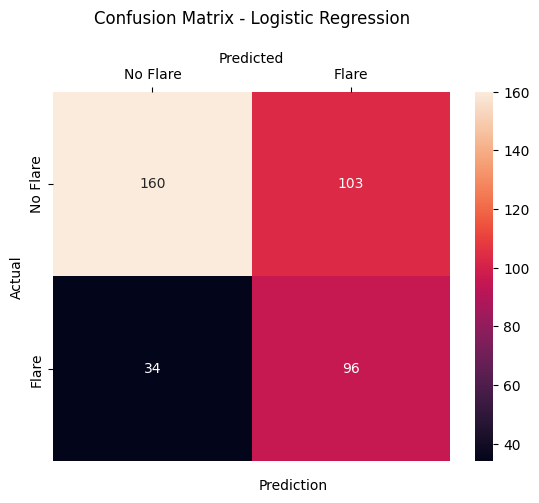

In [78]:
cm = confusion_matrix(y, y_pred_lr)

sns.heatmap(cm, 
            annot=True, 
            fmt='g',
            xticklabels=['No Flare', 'Flare'],
            yticklabels=['No Flare', 'Flare'])

plt.ylabel('Actual', fontsize=10)
plt.title('Confusion Matrix - Logistic Regression', fontsize=12, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Predicted', fontsize=10)
plt.gca().xaxis.tick_top()
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=10)
plt.show()


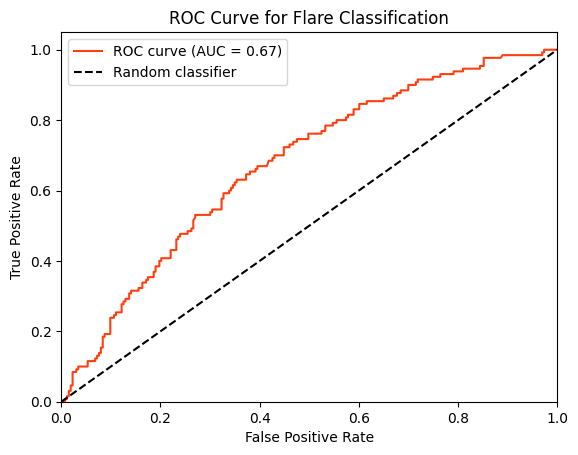

In [170]:
#Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y, y_prob_lr)
roc_auc = auc(fpr, tpr)

#Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color="#ff3f0f", lw=1.5, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Flare Classification')
plt.legend()
plt.show()

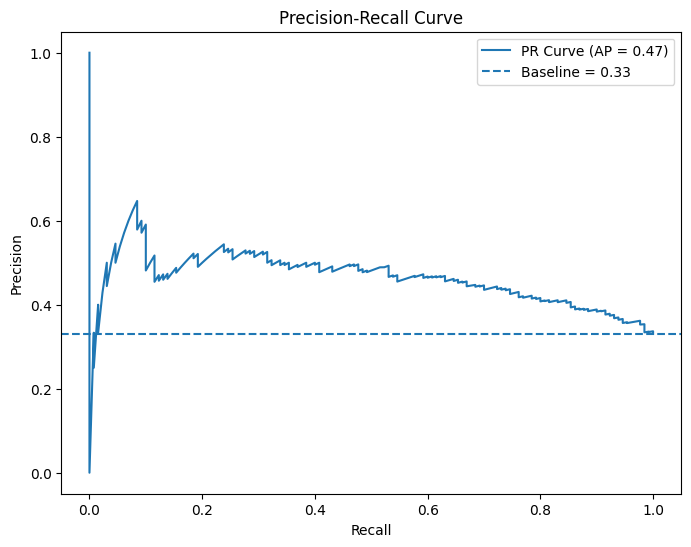

In [139]:
precision, recall, thresholds_pr = precision_recall_curve(y, y_prob_lr)
pr_auc = auc(recall, precision)
ap_score = average_precision_score(y, y_prob_lr)
baseline = y.mean()
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.2f})')
plt.axhline(y=baseline, linestyle='--', label=f'Baseline = {baseline:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [51]:
selector__lr= RFE(
    estimator=LogisticRegression(
        l1_ratio=1,
        solver='liblinear',
        C=0.1,
        class_weight='balanced',
        max_iter=1000,
        random_state=42 
),
    n_features_to_select=4,
    step=1
)


model__lr = LogisticRegression(
    l1_ratio=0,                     
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

model_pipeline__lr = Pipeline(steps=[
    ('preprocessor', clone(preprocessor_baseline)),
    ('selector_lr', selector__lr),
    ('classifier', model__lr)
])


param_grid_lr = {
    
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__class_weight': ['balanced', None],
    'classifier__solver': ['lbfgs', 'liblinear']
 }

grid__lr = GridSearchCV(
    estimator=model_pipeline__lr,
    param_grid=param_grid_lr,
    cv=stratified_group_kfold,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid__lr.fit(X, y, groups=groups)

print("Best params:", grid__lr.best_params_)
print("Best CV score:", grid__lr.best_score_)

best__lr = grid__lr.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'classifier__C': 0.001, 'classifier__class_weight': None, 'classifier__solver': 'lbfgs'}
Best CV score: 0.6814613854671909


In [52]:
y__pred_lr = cross_val_predict(best__lr, X, y, cv=stratified_group_kfold, groups=groups, method='predict')
y__prob_lr = cross_val_predict(best__lr, X, y, cv=stratified_group_kfold, groups=groups, method='predict_proba')[:, 1]

# # y_threshold_lr = 0.32  # Default threshold
# y_pred_lr = (y_prob_lr >= y_threshold_lr).astype(int)

# Compute and display metrics
print("\n" + "="*60)
print("LOGISTIC REGRESSION - RESULTS")
print("="*60)
print(classification_report(y, y__pred_lr, zero_division=0))
print(f"ROC AUC: {roc_auc_score(y, y__prob_lr):.2f}")
print("="*60)


LOGISTIC REGRESSION - RESULTS
              precision    recall  f1-score   support

           0       0.67      1.00      0.80       263
           1       0.00      0.00      0.00       130

    accuracy                           0.67       393
   macro avg       0.33      0.50      0.40       393
weighted avg       0.45      0.67      0.54       393

ROC AUC: 0.67


#### Random Forest

In [19]:
# Embedded feature selection with Random Forest importances
selector_rf = SelectFromModel(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        criterion='gini',
        n_estimators=100,
        random_state=42,
        n_jobs=1
    ),
    threshold='median'
)

model_rf = RandomForestClassifier(
    criterion='gini',
    random_state=42,
    n_jobs=1
)

model_pipeline_rf = Pipeline(steps=[
    ('preprocessor', clone(preprocessor_baseline)),
    ('selector', selector_rf),
    ('classifier', model_rf)
])

param_grid_rf = {
    'selector__estimator__n_estimators': [100, 300],
    'selector__threshold': ['median', 'mean'],
    'classifier__n_estimators': [100, 300],
    'classifier__max_depth': [3, 5, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 3, 5],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}

grid_rf = GridSearchCV(
    estimator=model_pipeline_rf,
    param_grid=param_grid_rf,
    cv=stratified_group_kfold,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X, y, groups=groups)

print("Best params:", grid_rf.best_params_)
print("Best CV score:", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_

Fitting 5 folds for each of 576 candidates, totalling 2880 fits
Best params: {'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': 3, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 3, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300, 'selector__estimator__n_estimators': 300, 'selector__threshold': 'mean'}
Best CV score: 0.6621521342711473


In [114]:
y_prob_rf = cross_val_predict(best_rf,
                            X,
                            y,
                            cv=stratified_group_kfold,
                            groups=groups,
                            method='predict_proba')[:, 1]


y_pred_adjusted = (y_prob_rf >= 0.35).astype(int)
y_pred_default = (y_prob_rf >= 0.5).astype(int)

print("Random Forest - Default Threshold (0.5):")
print(classification_report(y, y_pred_default))
print(f"Accuracy: {accuracy_score(y, y_pred_default):.2f}")

print("Random Forest - Adjusted Threshold (0.35):")
print(classification_report(y, y_pred_adjusted))
print(f"Accuracy: {accuracy_score(y, y_pred_adjusted):.2f}")

roc_auc = roc_auc_score(y, y_prob_rf)
print(f"ROC AUC: {roc_auc:.2f}")

Random Forest - Default Threshold (0.5):
              precision    recall  f1-score   support

           0       0.74      0.70      0.72       263
           1       0.46      0.52      0.48       130

    accuracy                           0.64       393
   macro avg       0.60      0.61      0.60       393
weighted avg       0.65      0.64      0.64       393

Accuracy: 0.64
Random Forest - Adjusted Threshold (0.35):
              precision    recall  f1-score   support

           0       0.87      0.27      0.42       263
           1       0.38      0.92      0.54       130

    accuracy                           0.49       393
   macro avg       0.63      0.59      0.48       393
weighted avg       0.71      0.49      0.46       393

Accuracy: 0.49
ROC AUC: 0.66


In [18]:
# 1. Extract the preprocessor and selector from the winning pipeline
best_preprocessor = best_rf.named_steps['preprocessor']
best_selector = best_rf.named_steps['selector']
best_classifier = best_rf.named_steps['classifier']

# 2. Get the dynamically generated feature names out of the ColumnTransformer
feature_names = best_preprocessor.get_feature_names_out()

# 3. Get the True/False mask of which features the selector decided to keep
survivor_mask = best_selector.get_support()
surviving_features = feature_names[survivor_mask]

print(f"Total Features Before Selection: {len(feature_names)}")
print(f"Total Features SURVIVED: {len(surviving_features)}\n")
print("--- The Winning Clinical Features ---")
for feature in surviving_features:
    # Clean up the output names for readability
    clean_name = feature.replace('cont__', '').replace('das28__', '').replace('bin__', '').replace('cat__', '')
    print(f"- {clean_name}")

Total Features Before Selection: 30
Total Features SURVIVED: 11

--- The Winning Clinical Features ---
- das28_change
- log_esr
- log_crp_normalized
- mtx_dose
- age_at_visit
- log_disease_duration
- days_since_last_visit
- comorbidity_count
- treatment_count
- das28_score
- das28_change


In [25]:
cm = confusion_matrix(y, y_pred_rf)
cm

array([[173,  90],
       [ 53,  77]])

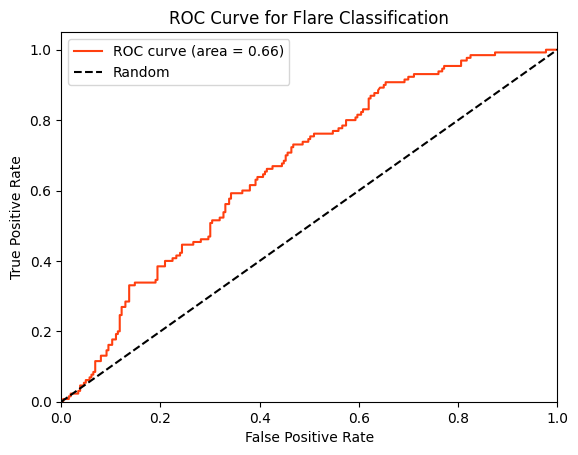

In [26]:
#Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y, y_prob_rf)
roc_auc = auc(fpr, tpr)

#Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color="#ff3f0f", lw=1.5, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Flare Classification')
plt.legend()
plt.show()

#### XGBoost
randomizedsearchCV

In [ ]:
model_xgb = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=2, 
    random_state=42,
    eval_metric='auc',
    n_jobs=1
    
)

preprocessor = ColumnTransformer(transformers=[
    ('cont', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())]), continuous_features),
    ('das28', das28_transformer, das28_feature),
    ('bin', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent'))]), binary_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
 ])

model_pipeline_xgb = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', model_xgb)
])

param_grid_xgb = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [2, 3, 5],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__min_child_weight': [1, 3, 5],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
    'classifier__reg_alpha': [0, 0.1, 1],
    'classifier__reg_lambda': [1, 5],
}

grid_xgb = GridSearchCV(
    estimator=model_pipeline_xgb,
    param_grid=param_grid_xgb,
    cv=group_kfold,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X, y, groups=groups)

print("Best params:", grid_xgb.best_params_)
print("Best CV score:", grid_xgb.best_score_)

best_xgb = grid_xgb.best_estimator_


Fitting 5 folds for each of 2916 candidates, totalling 14580 fits
Best params: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 2, 'classifier__min_child_weight': 5, 'classifier__n_estimators': 100, 'classifier__reg_alpha': 1, 'classifier__reg_lambda': 5, 'classifier__subsample': 0.6}
Best CV score: 0.6736827943721634


In [ ]:
y_pred_xgb, y_prob_xgb, metrics_xgb = evaluate_model(
    best_xgb, X, y, groups, group_kfold, "XGBoost"
)

              precision    recall  f1-score   support

           0       0.76      0.62      0.68       263
           1       0.44      0.60      0.51       130

    accuracy                           0.61       393
   macro avg       0.60      0.61      0.59       393
weighted avg       0.65      0.61      0.62       393

Accuracy: 0.61
ROC AUC: 0.64


### SVM

classifiers decision boundaries subplots -> visualization
